In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast

In [23]:
lake_name = 'neuchatel'
folder_path = rf"/storage/alplakes_test/{lake_name}_100m_2025"
input_folder = os.path.join(folder_path, "outputs_swirl", "eddy_catalogues_final")

output_folder = os.path.join(folder_path, "outputs_swirl", "eddy_statistics")
os.makedirs(output_folder, exist_ok=True)

# Import lvl2 catalogue

In [24]:
lvl2_csv_path = os.path.join(input_folder, "lvl2.csv")

In [25]:
df_lvl2 = pd.read_csv(lvl2_csv_path)
df_lvl2 = df_lvl2.set_index('id', drop=False)

In [26]:
lake_mask = np.load(os.path.join(folder_path, "grid", "mask_lake.npy"))

In [27]:
Nz, Ny, Nx = lake_mask.shape
mask = np.zeros((Nx, Ny)).T
mask[~lake_mask[0]] = np.nan

In [28]:
depths = pd.read_csv(os.path.join(folder_path, "grid", "depths.csv"))

In [8]:
def to_array(x):
    if isinstance(x, str):
        return np.array(ast.literal_eval(x))
    return np.array(x)

In [9]:
df_lvl2['volume(t)_[m3]'] = df_lvl2['volume(t)_[m3]'].apply(lambda s: to_array(s))

In [10]:
df_lvl2['kinetic_energy(t)_[MJ]'] = df_lvl2['kinetic_energy(t)_[MJ]'].apply(lambda s: to_array(s))

In [11]:
df_lvl2['volume(t)_[m3]'] = df_lvl2['volume(t)_[m3]'].apply(lambda s: to_array(s))

In [12]:
df_lvl2['dates(t)'] = df_lvl2['dates(t)'].apply(lambda s: pd.to_datetime(ast.literal_eval(s)))

In [13]:
df_lvl2['time_indices(t)'] = df_lvl2['time_indices(t)'].apply(lambda s: to_array(s))

In [14]:
df_lvl2['xc(t)'] = df_lvl2['xc(t)'].apply(lambda s: to_array(s))
df_lvl2['yc(t)'] = df_lvl2['yc(t)'].apply(lambda s: to_array(s))

# Life span statistics

In [29]:
df_lvl2['lifespan_[h]'] += 1

In [32]:
df_crop = df_lvl2[df_lvl2['lifespan_[h]'] > 1]

In [33]:
import matplotlib.pyplot as plt

table = pd.DataFrame({
    "Statistic": [
        "Count",
        "Mean",
        "Median",
        "Std",
        "Min",
        "90th percentile",
        "99th percentile",
        "Max"
    ],
    "Value [h]": [
        len(df_crop),
        df_crop['lifespan_[h]'].mean(),
        df_crop['lifespan_[h]'].median(),
        df_crop['lifespan_[h]'].std(),
        df_crop['lifespan_[h]'].min(),
        df_crop['lifespan_[h]'].quantile(0.90),
        df_crop['lifespan_[h]'].quantile(0.99),
        df_crop['lifespan_[h]'].max()
    ]
})

print(table.to_string(index=False))

      Statistic     Value [h]
          Count 245514.000000
           Mean      5.419561
         Median      3.000000
            Std      9.559468
            Min      2.000000
90th percentile     10.000000
99th percentile     39.000000
            Max    811.000000


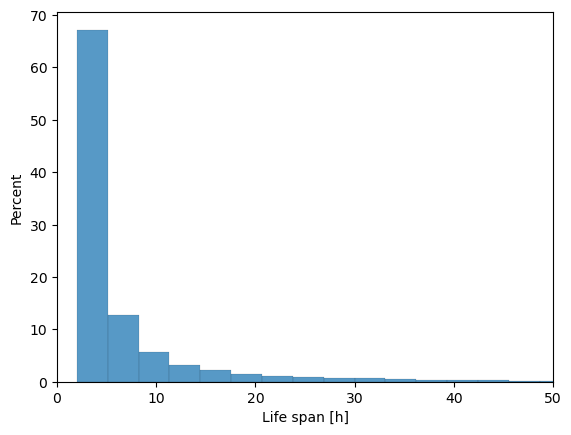

In [14]:
fig, ax = plt.subplots()
sns.histplot(
    df_lvl2['lifespan_[h]'][df_lvl2['lifespan_[h]']>1],
    bins=500,
    stat="percent")
plt.xlabel("Life span [h]")
plt.xlim(0,50)
plt.savefig(os.path.join(output_folder, "lifespan_statistics.png"))

In [22]:
df_lvl2['mean_volume_[km3]'] =  df_lvl2['volume(t)_[m3]'].apply(lambda s: s.mean()/ 1e9)

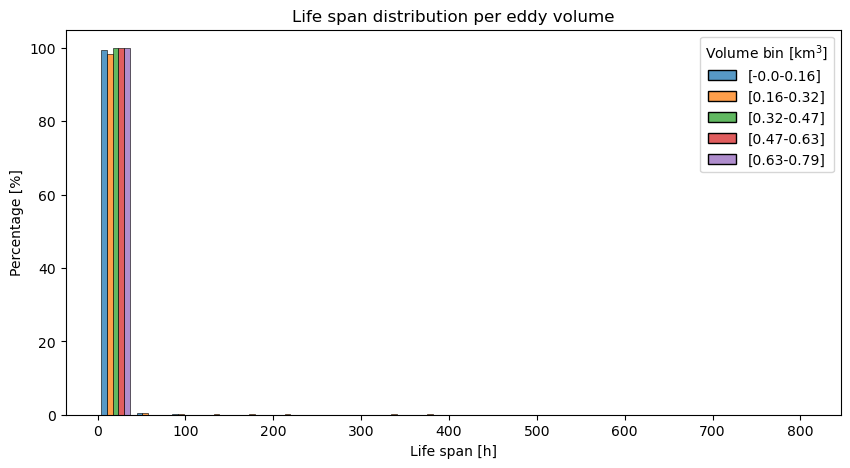

In [23]:
# Step 1: create bins and label them with min-max ranges
num_bins = 5
bins = pd.cut(df_lvl2['mean_volume_[km3]'], bins=num_bins)

# Create labels like "[min-max]"
bin_labels = [
    f"[{round(interval.left, 2)}-{round(interval.right, 2)}]"
    for interval in bins.cat.categories
]

df_lvl2['Volume bin [km$^3$]'] = pd.cut(
    df_lvl2['mean_volume_[km3]'],
    bins=num_bins,
    labels=bin_labels
)

# Step 2: plot histogram with percentages per bin
fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(
    data=df_lvl2,
    x='lifespan_[h]',
    hue='Volume bin [km$^3$]',
    bins=20,
    stat='percent',
    multiple='dodge',
    common_norm=False,  # percentages normalized per volume bin
    shrink=0.8
)

ax.set_xlabel("Life span [h]")
ax.set_ylabel("Percentage [%]")
plt.title("Life span distribution per eddy volume")
plt.savefig(os.path.join(output_folder, "lifespan_statistics_per_volume.png"))

# Eddy trajectories

In [ ]:
plt.imshow(mask, cmap='Blues', origin="lower")

In [ ]:
def compute_distance(row):
    xcs = to_array(row["xc(t)"])
    ycs = to_array(row["yc(t)"])
    return np.sqrt((xcs[-1] - xcs[0])**2 + (ycs[-1] - ycs[0])**2)

In [ ]:
df_lvl2['distance_traveled_[m]'] = df_lvl2.apply(compute_distance, axis=1).to_list()

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(mask, cmap='Blues', origin="lower")
plt.grid(False)

df_long_distances = df_lvl2[df_lvl2['distance_traveled_[m]']>50]
# Plot all trajectories
for xcs, ycs, tcs in zip(df_long_distances['xc(t)'],
                          df_long_distances['yc(t)'],
                          df_long_distances['time_indices(t)']):
    plt.scatter(xcs, ycs, c=tcs, s=0.2, alpha=0.9)

plt.savefig(os.path.join(output_folder, "long_trajectories.png"))

In [ ]:
plt.figure(figsize=(10, 5))
plt.imshow(mask, cmap='Blues', origin="lower")
plt.grid(False)

id = 7787
plt.scatter(df_lvl2.iloc[id]['xc(t)'], df_lvl2.iloc[id]['yc(t)'], c=df_lvl2.iloc[id]['time_indices(t)'], s=0.2)
plt.colorbar(label='Time indices')

# KE

In [ ]:
for _, row in df_lvl2[df_lvl2['lifespan_[h]'] > 500].iterrows():
    ke_norm = row['kinetic_energy(t)_[MJ]'] / row['kinetic_energy(t)_[MJ]'].max()
    plt.plot(ke_norm, marker='x', ms='1', linestyle='', alpha=0.7)

plt.xlim(0, 1000)
plt.xticks(rotation=25)
plt.xlabel("Time index")
plt.ylabel("Kinetic Energy [MJ]")
plt.title("Kinetic energy curves for long-lived samples")
plt.show()
